# sample3 - 回帰（住宅価格）

カリフォルニア住宅データセットを使って数値を予測する**回帰**を学びます。

| ステップ | 内容 |
|----------|------|
| 1 | データ準備 |
| 2 | モデル定義 |
| 3 | 学習 |
| 4 | 評価・可視化 |

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # GPU を無効化して CPU で実行
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
print("TensorFlow:", tf.__version__)

I0000 00:00:1771826750.207809  109876 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1771826751.163021  109876 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.22.0-dev20260222


## 1. データ準備

In [2]:
housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train:", X_train.shape)

X_train: (16512, 8)


## 2. モデル定義

回帰の出力層は活性化関数なし・出力1次元です。

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # 出力1次元・活性化なし
])

model.compile(
    optimizer='adam',
    loss='mse',          # 平均二乗誤差
    metrics=['mae']      # 平均絶対誤差
)
model.summary()

/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## 3. 学習

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
print("学習完了")

学習完了


## 4. 評価・可視化

In [5]:
y_pred = model.predict(X_test, verbose=0).flatten()

print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")

MAE : 0.3509
R²  : 0.7933


/tmp/ipykernel_109876/3540260596.py:22: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109876/3540260596.py:22: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109876/3540260596.py:22: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109876/3540260596.py:22: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109876/3540260596.py:22: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fi

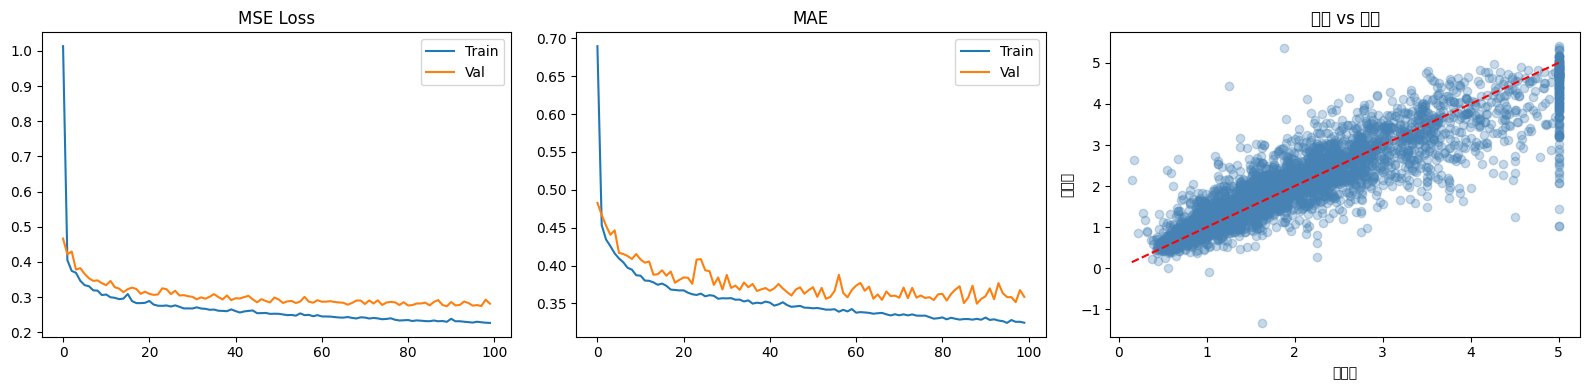

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('MSE Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].legend()

# 正解 vs 予測
axes[2].scatter(y_test, y_pred, alpha=0.3, color='steelblue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_xlabel('正解値')
axes[2].set_ylabel('予測値')
axes[2].set_title('正解 vs 予測')

plt.tight_layout()
plt.show()